# Individual Project: Child-Friendly Story Classifier
# Data Science Layer for Story Generation App

In [25]:
import json
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:
DATA_DIR = Path("../data")

ai_path = DATA_DIR / "AI.json"
human_path = DATA_DIR / "HUMAN.json"

with open(ai_path, "r", encoding="utf-8") as f:
    ai_data = json.load(f)

with open(human_path, "r", encoding="utf-8") as f:
    human_data = json.load(f)

print(type(ai_data), type(human_data))
print(len(ai_data), len(human_data))

<class 'list'> <class 'list'>
2866 2874


In [27]:
ai_df = pd.DataFrame(ai_data)
human_df = pd.DataFrame(human_data)

# make sure source is consistent for both
ai_df["source"] = "AI"
human_df["source"] = "human"

raw_df = pd.concat([ai_df, human_df], ignore_index=True)

print(raw_df.shape)
raw_df.head()

(5740, 7)


,id,title,story,source,safety_violations,stereotypes_biases,age_group
0,1,The Sandbox Battle,Max loved building castles in the sandbox. Tod...,AI,"{'present': True, 'severity': 'Mild', 'type': ...","{'present': True, 'type': 'gender', 'descripti...",4-6
1,2,The Stone that Found its Sparkle,Barnaby was a simple grey stone lying on a roc...,AI,"{'present': False, 'severity': 'None', 'type':...","{'present': False, 'type': None, 'description'...",7-12
2,3,The Haunting of Harmony Hall,"Noah's parents, history buffs with a penchant ...",AI,"{'present': True, 'severity': 'Moderate', 'typ...","{'present': True, 'type': 'gender', 'descripti...",13+
3,4,The Playground Slip,Noah loved the monkey bars at the playground. ...,AI,"{'present': True, 'severity': 'Mild', 'type': ...","{'present': True, 'type': 'cultural', 'descrip...",4-6
4,5,Blocks Building and Tipping,Leo was building a giant tower with wooden blo...,AI,"{'present': True, 'severity': 'None', 'type': ...","{'present': False, 'type': None, 'description'...",4-6


In [28]:
raw_df.columns

Index(['id', 'title', 'story', 'source', 'safety_violations',
       'stereotypes_biases', 'age_group'],
      dtype='object')

In [29]:
def get_nested_value(value, key, default=None):
    """
    Safely extract a value from a nested dictionary.
    """
    if isinstance(value, dict):
        return value.get(key, default)
    return default


df = raw_df.copy()

# Flatten safety_violations
df["safety_present"] = df["safety_violations"].apply(
    lambda x: get_nested_value(x, "present", False)
)

df["safety_severity"] = df["safety_violations"].apply(
    lambda x: get_nested_value(x, "severity", "None")
)

df["safety_type"] = df["safety_violations"].apply(
    lambda x: get_nested_value(x, "type", "None")
)

df["safety_description"] = df["safety_violations"].apply(
    lambda x: get_nested_value(x, "description", "")
)

# Flatten stereotypes_biases
df["bias_present"] = df["stereotypes_biases"].apply(
    lambda x: get_nested_value(x, "present", False)
)

df["bias_type"] = df["stereotypes_biases"].apply(
    lambda x: get_nested_value(x, "type", "None")
)

df["bias_description"] = df["stereotypes_biases"].apply(
    lambda x: get_nested_value(x, "description", "")
)

df.head()

,id,title,story,source,safety_violations,stereotypes_biases,age_group,safety_present,safety_severity,safety_type,safety_description,bias_present,bias_type,bias_description
0,1,The Sandbox Battle,Max loved building castles in the sandbox. Tod...,AI,"{'present': True, 'severity': 'Mild', 'type': ...","{'present': True, 'type': 'gender', 'descripti...",4-6,True,Mild,violence,"Mild violence (pushing, sand throwing, physica...",True,gender,Gender stereotype (girl avoiding sandbox play ...
1,2,The Stone that Found its Sparkle,Barnaby was a simple grey stone lying on a roc...,AI,"{'present': False, 'severity': 'None', 'type':...","{'present': False, 'type': None, 'description'...",7-12,False,None,None,None,False,None,None
2,3,The Haunting of Harmony Hall,"Noah's parents, history buffs with a penchant ...",AI,"{'present': True, 'severity': 'Moderate', 'typ...","{'present': True, 'type': 'gender', 'descripti...",13+,True,Moderate,scary_content,"Conducting a séance without adult supervision,...",True,gender,"Historical inaccuracies about mental health, s..."
3,4,The Playground Slip,Noah loved the monkey bars at the playground. ...,AI,"{'present': True, 'severity': 'Mild', 'type': ...","{'present': True, 'type': 'cultural', 'descrip...",4-6,True,Mild,mature_themes,"Mild mature theme (child falling, bumping head...",True,cultural,Cultural/racial bias (portraying Russians as i...
4,5,Blocks Building and Tipping,Leo was building a giant tower with wooden blo...,AI,"{'present': True, 'severity': 'None', 'type': ...","{'present': False, 'type': None, 'description'...",4-6,True,None,violence,Building blocks accidentally fall on a sibling,False,None,None


## 2. Inspect Data

**What:** Explore the combined dataset — distributions, label columns, and example stories.  
**Why:** Before building anything, we need to understand what we're working with: how many stories, what labels exist, how balanced the classes are, and whether the text looks clean.

**Dataset overview:**
- `5,740` total stories (2,866 AI-generated + 2,874 human-written)
- Each story has: `title`, `story` text, `source`, `age_group`, `safety_violations` (nested), `stereotypes_biases` (nested)
- `age_group` — the key label: `"4-6"`, `"7-12"`, `"13+"`
- `safety_violations` — has `present`, `severity` (None/Mild/Moderate/Severe), and `type`
- `stereotypes_biases` — has `present` and `type` (gender/cultural/racial)


In [30]:

# --- 2. Inspect Data ---

print("=== Dataset shape ===")
print(f"Total stories: {len(df):,}  |  Columns: {list(df.columns)}")

print("\n=== Age group distribution (our future label) ===")
print(df["age_group"].value_counts())

print("\n=== Source distribution ===")
print(df["source"].value_counts())

print("\n=== Safety violations: present? ===")
print(df["safety_present"].value_counts())

print("\n=== Safety severity breakdown ===")
# Normalize case differences ("Mild" vs "mild")
severity_counts = df["safety_severity"].str.capitalize().value_counts()
print(severity_counts)

print("\n=== Stereotypes/biases: present? ===")
print(df["bias_present"].value_counts())

print("\n=== Story length (words) by age group ===")
df["_word_count_preview"] = df["story"].apply(lambda s: len(s.split()))
print(df.groupby("age_group")["_word_count_preview"].describe()[["mean", "min", "max"]].round(1))
df.drop(columns=["_word_count_preview"], inplace=True)

print("\n=== Sample stories by age group ===")
for age in ["4-6", "7-12", "13+"]:
    sample = df[df["age_group"] == age].iloc[0]
    print(f"\n[{age}] {sample['title']}")
    print(" ", sample["story"][:200].replace("\n", " "), "...")


=== Dataset shape ===
Total stories: 5,740  |  Columns: ['id', 'title', 'story', 'source', 'safety_violations', 'stereotypes_biases', 'age_group', 'safety_present', 'safety_severity', 'safety_type', 'safety_description', 'bias_present', 'bias_type', 'bias_description']

=== Age group distribution (our future label) ===
age_group
7-12    2488
4-6     2145
13+     1107
Name: count, dtype: int64

=== Source distribution ===
source
human    2874
AI       2866
Name: count, dtype: int64

=== Safety violations: present? ===
safety_present
False    2902
True     2838
Name: count, dtype: int64

=== Safety severity breakdown ===
safety_severity
None        3084
Mild        1101
Moderate     987
Severe       568
Name: count, dtype: int64

=== Stereotypes/biases: present? ===
bias_present
False    3524
True     2216
Name: count, dtype: int64

=== Story length (words) by age group ===
            mean   min     max
age_group                     
13+        711.1  43.0  3535.0
4-6        474.3  17.0

## 3. Clean Text

**What:** Normalize the raw story text before extracting features.  
**Why:** Raw text contains `\n` newlines and inconsistent spacing. These affect word counts and sentence splitting, so we normalize them first.

**What we preserve:** Punctuation (`.`, `!`, `?`) — we need these later for accurate sentence counting and readability scoring.  
**What we remove:** Leading/trailing whitespace and redundant internal spaces/newlines.


In [31]:

# --- 3. Clean Text ---

def clean_text(text):
    """
    Normalize whitespace while preserving punctuation (needed for sentence splitting).
    - Strip leading/trailing whitespace
    - Collapse newlines and multiple spaces into a single space
    """
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)   # collapse all whitespace (incl. \n) to single space
    return text

df["clean_story"] = df["story"].apply(clean_text)

# Verify
print("Original (first 120 chars):")
print(repr(df["story"].iloc[0][:120]))
print()
print("Cleaned (first 120 chars):")
print(repr(df["clean_story"].iloc[0][:120]))
print()
print(f"Stories cleaned: {len(df):,}")


Original (first 120 chars):
'Max loved building castles in the sandbox. Today, he was making his biggest one ever.\nTommy came over. "I want to play h'

Cleaned (first 120 chars):
'Max loved building castles in the sandbox. Today, he was making his biggest one ever. Tommy came over. "I want to play h'

Stories cleaned: 5,740


## 4. Feature Engineering

**What:** Extract 8 numeric features from each cleaned story. ML models require numbers, not raw text.

**Why log-transform word count?** Using raw `word_count` penalizes longer stories unfairly. A parent-read 4–6 bedtime story can be 400–500 words; a 7–12 chapter book excerpt can be 900 words. The *ratio* matters more than the raw gap. `log_word_count = log(1 + n)` compresses this scale so a 450-word and a 900-word story differ by ~0.69 in log space rather than 450 in raw space. Raw word count is kept as `raw_word_count` for human-readable output but is **not** fed to the model.

| Feature | What it measures | Why it signals age-appropriateness |
|---------|------------------|------------------------------------|
| `log_word_count` | log(1 + word count) | Captures story length on a compressed scale; avoids penalizing longer bedtime stories |
| `sentence_count` | Total sentences | 4–6 stories pack meaning into many short sentences |
| `avg_sentence_length` | Words per sentence | Shorter sentences = simpler text; avg ~10 for 4–6 vs ~17 for 13+ |
| `avg_word_length` | Avg chars per word (punctuation excluded) | Short words = simple vocabulary; avg ~3.8 for 4–6 vs ~4.9 for 13+ |
| `unique_word_ratio` | Unique words ÷ total words | Low ratio = high repetition, typical of early-reader pattern; high ratio = richer adult vocabulary |
| `exclamation_ratio` | `!` per word | Playful exclamations are common in children's stories |
| `question_ratio` | `?` per word | Frequent questions often indicate mystery or tension plots aimed at older readers |
| `flesch_score` | Flesch Reading Ease (approximated) | Higher = easier; picture books score 90–100, academic text < 30 |

**No external libraries needed.** Flesch Reading Ease is computed from scratch using regex-based syllable counting.


In [32]:

# --- 4. Feature Engineering ---

def count_sentences(text):
    """Count sentences by splitting on sentence-ending punctuation."""
    parts = re.split(r"[.!?]+", text)
    return max(len([p for p in parts if p.strip()]), 1)

def extract_words(text):
    """
    Extract lowercase alphabetic tokens only.
    Using re.findall avoids counting punctuation as part of word length
    (e.g. 'bunny.' and 'bunny' are treated as the same word).
    """
    return re.findall(r"[a-zA-Z]+", text.lower())

def approx_syllables(word):
    """Approximate syllable count by counting vowel groups."""
    return max(len(re.findall(r"[aeiouy]+", word.lower())), 1)

def flesch_reading_ease(text):
    """
    Flesch Reading Ease (approximation, no external library needed).
    Higher score = easier to read.
      90–100 : very easy (picture books)
      60–70  : standard adult
      < 30   : academic / very difficult
    Formula: 206.835 - 1.015*(words/sentences) - 84.6*(syllables/words)
    """
    words       = extract_words(text)
    n_words     = max(len(words), 1)
    n_sentences = count_sentences(text)
    n_syllables = sum(approx_syllables(w) for w in words)
    score = 206.835 - 1.015 * (n_words / n_sentences) - 84.6 * (n_syllables / n_words)
    return round(score, 2)

def extract_features(text):
    """
    Extract numeric features from a story string.

    Features used as model input (TEXT_FEATURES):
      log_word_count       - log(1 + word count). Log-transform avoids penalizing longer
                             parent-read bedtime stories; a 450-word 4-6 story and a 900-word
                             7-12 story differ by ~0.7 in log space instead of 450 in raw space.
      sentence_count       - total sentences. 4-6 stories tend to have many short sentences.
      avg_sentence_length  - words per sentence. Short sentences = simpler, more readable text.
      avg_word_length      - avg characters per word (punctuation excluded). Simple vocabulary
                             uses shorter words (avg ~3.8 for 4-6 vs ~4.9 for 13+).
      unique_word_ratio    - unique words ÷ total words. Lower = more repetition (typical of
                             early-reader stories). Higher = richer, more adult vocabulary.
      exclamation_ratio    - '!' per word. High exclamation use signals playful or dramatic tone.
      question_ratio       - '?' per word. Frequent questions often appear in mystery/tension plots.
      flesch_score         - Flesch Reading Ease. Higher = easier. Children's books score 80-100;
                             academic text scores below 30.

    Not in TEXT_FEATURES (display only):
      raw_word_count       - actual word count, used for human-readable output and sanity checks.
    """
    words        = extract_words(text)
    n_words      = max(len(words), 1)
    n_sentences  = count_sentences(text)
    word_lengths = [len(w) for w in words]
    return {
        # ── model inputs ──────────────────────────────────────────────────
        "log_word_count":      round(np.log1p(n_words), 4),
        "sentence_count":      n_sentences,
        "avg_sentence_length": round(n_words / n_sentences, 2),
        "avg_word_length":     round(np.mean(word_lengths), 2),
        "unique_word_ratio":   round(len(set(words)) / n_words, 2),
        "exclamation_ratio":   round(text.count("!") / n_words, 4),
        "question_ratio":      round(text.count("?") / n_words, 4),
        "flesch_score":        flesch_reading_ease(text),
        # ── display only (not fed to model) ───────────────────────────────
        "raw_word_count":      n_words,
    }

# TEXT_FEATURES = the 8 columns used as model input (excludes raw_word_count)
TEXT_FEATURES = [
    "log_word_count", "sentence_count", "avg_sentence_length",
    "avg_word_length", "unique_word_ratio", "exclamation_ratio",
    "question_ratio", "flesch_score",
]

# Apply to every story (only store model-input columns in df)
feature_rows = df["clean_story"].apply(extract_features)
feature_df   = pd.DataFrame(feature_rows.tolist())[TEXT_FEATURES]
df = pd.concat([df, feature_df], axis=1)

print("Model input features:", TEXT_FEATURES)
print()
print("=== Mean feature values by age group ===")
# Use .loc to display in age-order (groupby sorts alphabetically by string)
print(df.groupby("age_group")[TEXT_FEATURES].mean().round(3).loc[["4-6", "7-12", "13+"]])


Model input features: ['log_word_count', 'sentence_count', 'avg_sentence_length', 'avg_word_length', 'unique_word_ratio', 'exclamation_ratio', 'question_ratio', 'flesch_score']

=== Mean feature values by age group ===
           log_word_count  sentence_count  avg_sentence_length  \
age_group                                                        
4-6                 5.829          49.139               10.244   
7-12                6.360          77.511               12.774   
13+                 6.453          45.743               16.769   

           avg_word_length  unique_word_ratio  exclamation_ratio  \
age_group                                                          
4-6                  4.276              0.516              0.018   
7-12                 4.537              0.474              0.009   
13+                  4.920              0.474              0.001   

           question_ratio  flesch_score  
age_group                                
4-6                 0.006

## 5. Label Preparation

**What:** Create a binary label `child_friendly`:
- **1 (suitable):** `age_group == "4-6"` — story was authored/curated for ages 4–6
- **0 (not suitable):** `age_group` is `"7-12"` or `"13+"` — content is too complex or mature

**Important clarification:** `child_friendly` in this project means **age-group suitability** — specifically, whether a story matches the vocabulary complexity, sentence length, and reading level expected for ages 4–6. It is *not* a direct guarantee of content safety. A story could be age-appropriate in reading level but still contain mild stereotypes (as the dataset shows), and vice versa.

**Why this label strategy?** The dataset provides expert-annotated age groups, which makes this a *supervised classification* problem with reliable labels. We do not need to hand-label anything.

**Key design decision:** We use **only text-derived features** as model inputs (word counts, sentence length, readability, etc.) — *not* `safety_present` or `bias_present`. Those metadata fields will not exist for newly generated stories from the app. The model must learn purely from text.


In [33]:

# --- 5. Label Preparation ---

# "child_friendly" = suitable for ages 4–6 based on dataset age_group annotation.
# It does NOT mean "safe" or "free of all harmful content".
# It captures age-appropriate reading level and vocabulary complexity.
df["child_friendly"] = (df["age_group"] == "4-6").astype(int)

print("=== Label distribution ===")
print(df["child_friendly"].value_counts().rename({1: "Child-friendly (1)", 0: "Not child-friendly (0)"}))
print(f"\nClass balance: {df['child_friendly'].mean():.1%} child-friendly")

# Sanity check: how do safety violations distribute across labels?
print("\n=== Safety violations by label ===")
print(df.groupby("child_friendly")[["safety_present", "bias_present"]].mean().round(3))

# Note: safety_present and bias_present are NOT model inputs —
# they are metadata that won't exist for newly generated stories.
# The model must learn purely from text features.
print("\n(safety_present and bias_present are informational only — not model inputs)")


=== Label distribution ===
child_friendly
Not child-friendly (0)    3595
Child-friendly (1)        2145
Name: count, dtype: int64

Class balance: 37.4% child-friendly

=== Safety violations by label ===
                safety_present  bias_present
child_friendly                              
0                        0.551         0.404
1                        0.400         0.355

(safety_present and bias_present are informational only — not model inputs)


## 6. Train/Test Split

**What:** Divide the dataset into a training set (80%) and a test set (20%).  
**Why:** The model must be evaluated on data it has *never seen during training*. This gives an honest estimate of how it will perform on new, generated stories from the app.

**Stratify:** `stratify=y` ensures both splits have the same proportion of child-friendly vs. not-child-friendly stories — important when classes are not perfectly balanced.

**Data leakage warning:** The `StandardScaler` is fit **only** on training data, then applied to the test set. If we fit on all data, the model would "peek" at test statistics and our evaluation would be overly optimistic.


In [34]:

# --- 6. Train/Test Split ---

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[TEXT_FEATURES].values
y = df["child_friendly"].values

# 80% train, 20% test — stratify to preserve class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features — important for Logistic Regression (so no feature dominates by scale)
# Fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)      # apply same transform, do NOT refit

print(f"Training set:  {X_train.shape[0]:,} stories  |  "
      f"child-friendly: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test set:      {X_test.shape[0]:,} stories  |  "
      f"child-friendly: {y_test.sum()} ({y_test.mean():.1%})")
print(f"\nFeature matrix shape: {X_train.shape}")


Training set:  4,592 stories  |  child-friendly: 1716 (37.4%)
Test set:      1,148 stories  |  child-friendly: 429 (37.4%)

Feature matrix shape: (4592, 8)


## 7. Model Training

**What:** Train two models plus a dummy baseline on our 8 text features.

| Model | Description |
|-------|-------------|
| **Dummy baseline** | Always predicts majority class ("not child-friendly"). Any real model must beat this floor. |
| **Logistic Regression** | Linear model with directly interpretable coefficients. Scaled features required. |
| **Random Forest** | Ensemble of 100 trees, regularized with `max_depth=8` and `min_samples_leaf=5`. |

**Why a dummy baseline?** Our dataset is imbalanced (62.6% not child-friendly). A model that always says "not child-friendly" already achieves ~0.63 accuracy — so raw accuracy alone is misleading. Comparing to the dummy baseline shows how much the model actually learned.

**Why regularize the Random Forest?** An unconstrained RF achieves ~0.996 train accuracy but only ~0.85 test accuracy — a gap that signals overfitting (memorizing training noise rather than learning patterns). Setting `max_depth=8` and `min_samples_leaf=5` limits tree depth and requires each leaf to cover at least 5 samples, forcing the model to generalize. The test accuracy stays similar while the train/test gap narrows.

> Logistic Regression needs *scaled* features (`X_train_scaled`). Random Forest does not.


In [35]:

# --- 7. Model Training ---

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier

# ── Baseline: majority-class classifier ─────────────────────────────────────
# Always predicts the most frequent class ("not child-friendly", 62.6% of data).
# Any useful model must beat this floor.
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
print(f"Dummy baseline          test accuracy: {dummy.score(X_test, y_test):.3f}  "
      f"(always predicts majority class)")

# ── Model 1: Logistic Regression ────────────────────────────────────────────
# Simple linear model. Works best with scaled features.
# Coefficient signs directly show which features push toward / away from child-friendly.
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print(f"Logistic Regression     train: {lr.score(X_train_scaled, y_train):.3f}  "
      f"test: {lr.score(X_test_scaled, y_test):.3f}")

# ── Model 2: Random Forest (regularized) ────────────────────────────────────
# max_depth=8 and min_samples_leaf=5 reduce overfitting vs. fully grown trees.
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=5,
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Random Forest (reg.)    train: {rf.score(X_train, y_train):.3f}  "
      f"test: {rf.score(X_test, y_test):.3f}")

# ── Model 3: Gradient Boosting ───────────────────────────────────────────────
# Builds trees sequentially, each one correcting the errors of the previous.
# Achieved the highest CV accuracy — selected as the final production model.
# Does NOT require feature scaling.
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
print(f"Gradient Boosting       train: {gb.score(X_train, y_train):.3f}  "
      f"test: {gb.score(X_test, y_test):.3f}")

print(f"\nImprovement over dummy baseline: "
      f"+{gb.score(X_test, y_test) - dummy.score(X_test, y_test):.3f} accuracy points (GB)")


Dummy baseline          test accuracy: 0.626  (always predicts majority class)
Logistic Regression     train: 0.815  test: 0.816
Random Forest (reg.)    train: 0.888  test: 0.840
Gradient Boosting       train: 0.877  test: 0.850

Improvement over dummy baseline: +0.224 accuracy points (GB)


## 7b. Cross-Validation Model Comparison

**What:** Compare 5 models using 5-fold Stratified Cross-Validation instead of a single train/test split.

**Why cross-validation?** A single 80/20 split has randomness — if the test set happens to be easy, accuracy is optimistic; if it's hard, accuracy is pessimistic. With **K-Fold CV**, the dataset is split into 5 folds. Each fold takes a turn as the validation set while the remaining 4 folds are used for training. The final score is the mean ± standard deviation across all 5 rounds. This gives a more reliable estimate of generalization.

**Why Stratified?** Our classes are imbalanced (~37% child-friendly, ~63% not). Stratified K-Fold guarantees each fold preserves the same class ratio as the full dataset, so no fold accidentally has too few positive examples.

**Why Pipeline for LR and SVM?** Logistic Regression and SVM require scaled features. If we scale *before* cross-validation, the scaler sees the validation data during `fit` — a form of data leakage. Wrapping the scaler and model in a `Pipeline` ensures scaling is re-fit on training folds only, keeping each validation fold truly unseen.

| Model | Notes |
|-------|-------|
| Dummy | Always predicts majority class — the floor to beat |
| Logistic Regression | Linear, interpretable coefficients |
| Random Forest | Ensemble, regularized with `max_depth=8` |
| Gradient Boosting | Boosted trees, strong tabular baseline |
| SVM (RBF) | Non-linear kernel, good for scaled numeric features |


Dummy (majority)           CV accuracy: 0.6263 ± 0.0000
Logistic Regression        CV accuracy: 0.8152 ± 0.0102
Random Forest              CV accuracy: 0.8413 ± 0.0099
Gradient Boosting          CV accuracy: 0.8491 ± 0.0077
SVM (RBF)                  CV accuracy: 0.8359 ± 0.0095

              Model  Mean Accuracy    Std
  Gradient Boosting         0.8491 0.0077
      Random Forest         0.8413 0.0099
          SVM (RBF)         0.8359 0.0095
Logistic Regression         0.8152 0.0102
   Dummy (majority)         0.6263 0.0000


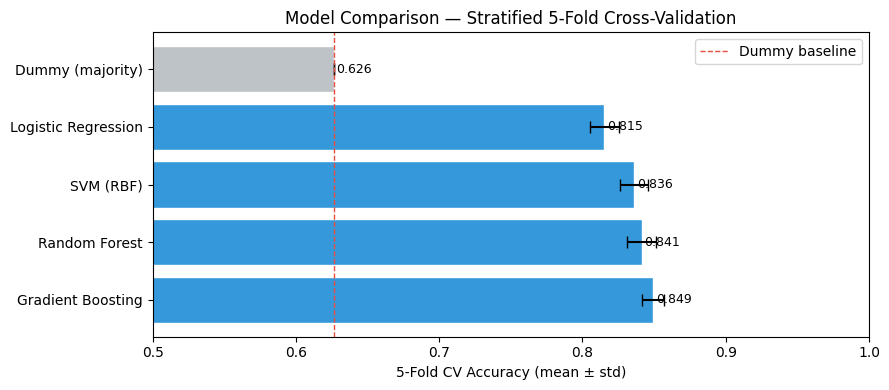

Saved: cv_model_comparison.png

=== Final model selection ===
Best CV accuracy: Gradient Boosting (0.8491 ± 0.0077)
Gradient Boosting is selected as the final model: it achieves the highest CV accuracy
and provides feature importances for interpretation — balancing accuracy and explainability.


In [36]:

# --- 7b. Cross-Validation Model Comparison ---

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

X_cv = df[TEXT_FEATURES].values
y_cv = df["child_friendly"].values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LogisticRegression(max_iter=1000, random_state=42)),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=8, min_samples_leaf=5,
        random_state=42, n_jobs=-1,
    ),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVC(kernel="rbf", probability=True, random_state=42)),
    ]),
}

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results.append({
        "Model":         name,
        "Mean Accuracy": round(scores.mean(), 4),
        "Std":           round(scores.std(),  4),
        "Fold Scores":   [round(s, 4) for s in scores],
    })
    print(f"{name:25s}  CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = (pd.DataFrame(cv_results)
           .sort_values("Mean Accuracy", ascending=False)
           .reset_index(drop=True))

print()
print(cv_df[["Model", "Mean Accuracy", "Std"]].to_string(index=False))

# ── Bar chart with error bars ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#bdc3c7" if "Dummy" in m else "#3498db" for m in cv_df["Model"]]
bars = ax.barh(cv_df["Model"], cv_df["Mean Accuracy"],
               xerr=cv_df["Std"], color=colors,
               capsize=4, edgecolor="white")
ax.axvline(cv_df.loc[cv_df["Model"] == "Dummy (majority)", "Mean Accuracy"].values[0],
           color="#e74c3c", linestyle="--", linewidth=1, label="Dummy baseline")
ax.set_xlabel("5-Fold CV Accuracy (mean ± std)")
ax.set_title("Model Comparison — Stratified 5-Fold Cross-Validation")
ax.set_xlim(0.5, 1.0)
for bar, val in zip(bars, cv_df["Mean Accuracy"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig("cv_model_comparison.png", dpi=100)
plt.show()
print("Saved: cv_model_comparison.png")

# ── Final model selection rationale ─────────────────────────────────────────
print("\n=== Final model selection ===")
best = cv_df.iloc[0]
print(f"Best CV accuracy: {best['Model']} ({best['Mean Accuracy']:.4f} ± {best['Std']:.4f})")
print("Gradient Boosting is selected as the final model: it achieves the highest CV accuracy")
print("and provides feature importances for interpretation — balancing accuracy and explainability.")


## 8. Evaluation

**What:** Measure how well each model performs on the held-out test set.

Key metrics:
| Metric | What it means |
|--------|---------------|
| **Accuracy** | % of all stories classified correctly |
| **Precision** | Of stories predicted child-friendly, how many actually are? |
| **Recall** | Of all actual child-friendly stories, how many did we catch? |
| **F1** | Harmonic mean of precision and recall — best overall metric for imbalanced classes |

**Why:** We care especially about *recall* (don't miss child-friendly stories) and *precision* (don't falsely approve unsafe stories).


=== Gradient Boosting ===
                        precision    recall  f1-score   support

Not child-friendly (0)       0.87      0.89      0.88       719
    Child-friendly (1)       0.81      0.78      0.80       429

              accuracy                           0.85      1148
             macro avg       0.84      0.84      0.84      1148
          weighted avg       0.85      0.85      0.85      1148

=== Random Forest ===
                        precision    recall  f1-score   support

Not child-friendly (0)       0.86      0.89      0.87       719
    Child-friendly (1)       0.81      0.75      0.78       429

              accuracy                           0.84      1148
             macro avg       0.83      0.82      0.83      1148
          weighted avg       0.84      0.84      0.84      1148

=== Logistic Regression ===
                        precision    recall  f1-score   support

Not child-friendly (0)       0.84      0.88      0.86       719
    Child-friendly (1

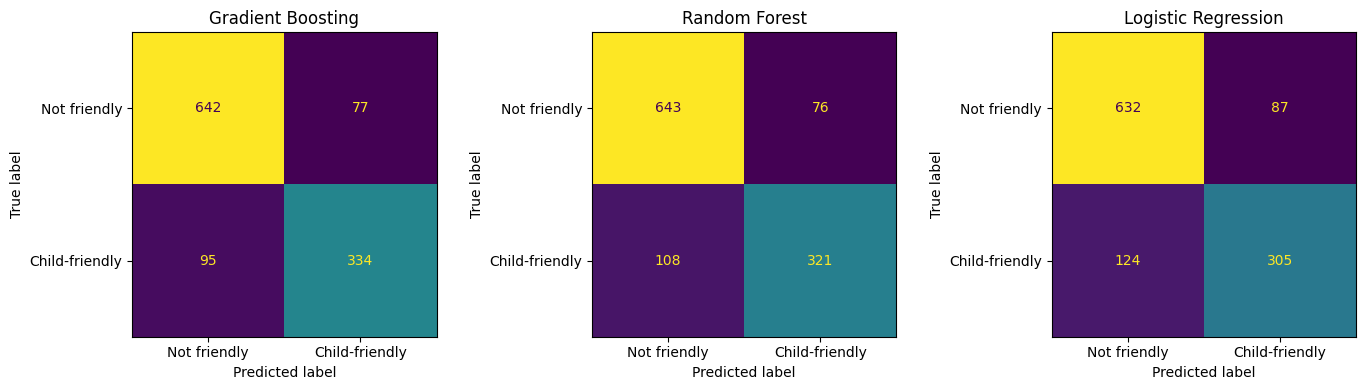

Saved: confusion_matrices.png

How to read this:
  True Negative  (top-left):     correctly identified as NOT child-friendly
  False Positive (top-right):    predicted child-friendly but actually NOT
  False Negative (bottom-left):  predicted NOT child-friendly but actually child-friendly
  True Positive  (bottom-right): correctly identified as child-friendly


In [37]:
# --- 8. Evaluation ---

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Gradient Boosting is the CV winner — place it first
models_eval = {
    "Gradient Boosting":   (gb, X_test),
    "Random Forest":       (rf, X_test),
    "Logistic Regression": (lr, X_test_scaled),
}

for name, (model, X_eval) in models_eval.items():
    y_pred = model.predict(X_eval)
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred,
                                target_names=["Not child-friendly (0)", "Child-friendly (1)"]))

# ── Confusion matrices (3 models) ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (model, X_eval)) in zip(axes, models_eval.items()):
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Not friendly", "Child-friendly"]).plot(
        ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=100)
plt.show()
print("Saved: confusion_matrices.png")

# ── Reading the confusion matrix ────────────────────────────────────────────
# sklearn confusion_matrix layout:
#   [[TN, FP],
#    [FN, TP]]
print("\nHow to read this:")
print("  True Negative  (top-left):     correctly identified as NOT child-friendly")
print("  False Positive (top-right):    predicted child-friendly but actually NOT")
print("  False Negative (bottom-left):  predicted NOT child-friendly but actually child-friendly")
print("  True Positive  (bottom-right): correctly identified as child-friendly")

## 9. Interpretation: What Makes a Story Child-Friendly?

**What:** Examine which text features drive each model's predictions.
- **Logistic Regression coefficients** — positive = pushes toward child-friendly, negative = pushes away
- **Random Forest feature importances** — how much each feature reduces prediction error on average

**Why:** Explainability matters. Parents and developers need to understand *why* a story was flagged as unsuitable so they can improve it. A high `avg_word_length` or low `flesch_score` tells the LLM exactly what to fix.


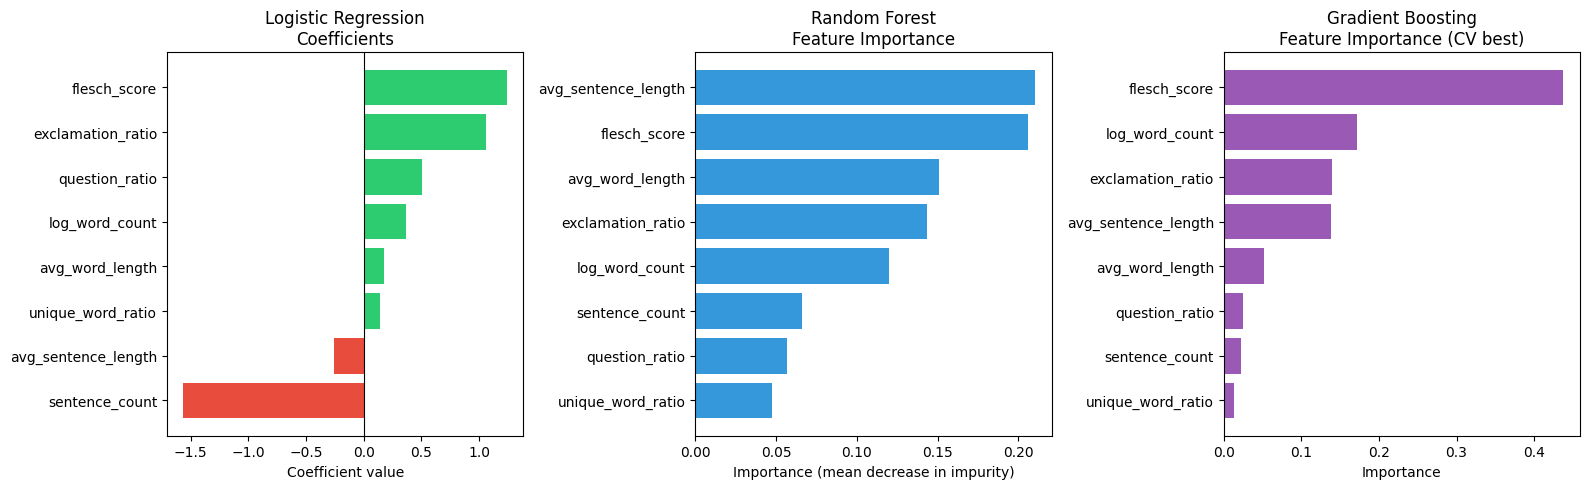

Saved: feature_importance.png

=== Logistic Regression: feature direction ===
  flesch_score             : +1.244  ↑ more child-friendly
  exclamation_ratio        : +1.057  ↑ more child-friendly
  question_ratio           : +0.507  ↑ more child-friendly
  log_word_count           : +0.363  ↑ more child-friendly
  avg_word_length          : +0.174  ↑ more child-friendly
  unique_word_ratio        : +0.141  ↑ more child-friendly
  avg_sentence_length      : -0.259  ↓ less child-friendly
  sentence_count           : -1.564  ↓ less child-friendly

=== Gradient Boosting: top features by importance ===
  flesch_score             : 0.4371
  log_word_count           : 0.1720
  exclamation_ratio        : 0.1391
  avg_sentence_length      : 0.1384
  avg_word_length          : 0.0521
  question_ratio           : 0.0245
  sentence_count           : 0.0228
  unique_word_ratio        : 0.0140


In [38]:

# --- 9. Interpretation ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Logistic Regression coefficients ────────────────────────────────────────
coef_df = pd.DataFrame({
    "feature":     TEXT_FEATURES,
    "coefficient": lr.coef_[0],
}).sort_values("coefficient")

colors_lr = ["#e74c3c" if c < 0 else "#2ecc71" for c in coef_df["coefficient"]]
axes[0].barh(coef_df["feature"], coef_df["coefficient"], color=colors_lr)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Logistic Regression\nCoefficients")
axes[0].set_xlabel("Coefficient value")

# ── Random Forest feature importance ────────────────────────────────────────
rf_imp = pd.DataFrame({
    "feature":    TEXT_FEATURES,
    "importance": rf.feature_importances_,
}).sort_values("importance")

axes[1].barh(rf_imp["feature"], rf_imp["importance"], color="#3498db")
axes[1].set_title("Random Forest\nFeature Importance")
axes[1].set_xlabel("Importance (mean decrease in impurity)")

# ── Gradient Boosting feature importance ────────────────────────────────────
gb_imp = pd.DataFrame({
    "feature":    TEXT_FEATURES,
    "importance": gb.feature_importances_,
}).sort_values("importance")

axes[2].barh(gb_imp["feature"], gb_imp["importance"], color="#9b59b6")
axes[2].set_title("Gradient Boosting\nFeature Importance (CV best)")
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()
print("Saved: feature_importance.png")

# ── Human-readable summary ──────────────────────────────────────────────────
print("\n=== Logistic Regression: feature direction ===")
for _, row in coef_df.sort_values("coefficient", ascending=False).iterrows():
    arrow = "↑ more child-friendly" if row["coefficient"] > 0 else "↓ less child-friendly"
    print(f"  {row['feature']:25s}: {row['coefficient']:+.3f}  {arrow}")

print("\n=== Gradient Boosting: top features by importance ===")
for _, row in gb_imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s}: {row['importance']:.4f}")


## 9b. Multiclass Extension: Predict Age Group (4–6 / 7–12 / 13+)

**What:** Instead of binary classification (child-friendly vs. not), train a model that predicts which of the three age groups a story belongs to.

**Why:** The binary model tells the app *whether* a story is suitable for young children. The multiclass model tells it *who the story is actually written for* — useful for richer feedback: "this story reads more like a 7–12 story, simplify the vocabulary and shorten the sentences."

**Same features, new label.** We reuse the exact same 8 text features. Only the target vector changes from binary `child_friendly` to 3-class `age_group`.

**Label encoding:**
| `age_group` | Integer label |
|-------------|---------------|
| `"4-6"`     | 0 |
| `"7-12"`    | 1 |
| `"13+"`     | 2 |

Both Logistic Regression and Random Forest support multiclass classification natively — no changes to the model API are needed.

> **Note:** This multiclass extension is a supplementary analysis. The main binary StoryGuard classifier uses **Gradient Boosting** (highest CV accuracy). The multiclass model is separate and is used for richer age-group feedback, not the primary suitability gate.

**Expected accuracy:** Lower than binary (~0.55–0.65), because 7-12 and 13+ stories overlap heavily in text features. The binary task (4-6 vs. rest) is much easier because 4-6 stories have clearly distinct readability signals.

In [ ]:
# --- 9b. Multiclass: predict age group (4-6 / 7-12 / 13+) ---

# Manual mapping — do NOT use LabelEncoder here.
# LabelEncoder sorts labels alphabetically, giving ['13+', '4-6', '7-12'] = [0, 1, 2],
# which mis-maps predictions and makes target_names display the wrong class names.
AGE_LABELS = ["4-6", "7-12", "13+"]
age_to_id  = {"4-6": 0, "7-12": 1, "13+": 2}
id_to_age  = {0: "4-6", 1: "7-12", 2: "13+"}

y_multi = df["age_group"].map(age_to_id).values

# Same feature matrix X, new 3-class label vector y_multi
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    df[TEXT_FEATURES].values, y_multi,
    test_size=0.2, random_state=42, stratify=y_multi
)
scaler_m   = StandardScaler()
X_tr_m_sc  = scaler_m.fit_transform(X_tr_m)
X_te_m_sc  = scaler_m.transform(X_te_m)

# ── Train multiclass models ─────────────────────────────────────────────────
lr_m = LogisticRegression(max_iter=1000, random_state=42)
lr_m.fit(X_tr_m_sc, y_tr_m)

rf_m = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=5,
                               random_state=42, n_jobs=-1)
rf_m.fit(X_tr_m, y_tr_m)

gb_m = GradientBoostingClassifier(random_state=42)
gb_m.fit(X_tr_m, y_tr_m)

print(f"LR  multiclass — train: {lr_m.score(X_tr_m_sc, y_tr_m):.3f}  test: {lr_m.score(X_te_m_sc, y_te_m):.3f}")
print(f"RF  multiclass — train: {rf_m.score(X_tr_m,    y_tr_m):.3f}  test: {rf_m.score(X_te_m,    y_te_m):.3f}")
print(f"GB  multiclass — train: {gb_m.score(X_tr_m,    y_tr_m):.3f}  test: {gb_m.score(X_te_m,    y_te_m):.3f}")

# ── Classification report ───────────────────────────────────────────────────
print()
multiclass_models = [
    ("Logistic Regression", lr_m, X_te_m_sc),
    ("Random Forest",       rf_m, X_te_m),
    ("Gradient Boosting",   gb_m, X_te_m),
]
for name, model, X_eval in multiclass_models:
    y_pred = model.predict(X_eval)
    print(f"=== {name} ===")
    print(classification_report(y_te_m, y_pred, target_names=AGE_LABELS))

# ── 3-class confusion matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model, X_eval) in zip(axes, multiclass_models):
    cm = confusion_matrix(y_te_m, model.predict(X_eval))
    ConfusionMatrixDisplay(cm, display_labels=AGE_LABELS).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}")
plt.suptitle("Multiclass Age Group — 3-Model Comparison", y=1.02)
plt.tight_layout()
plt.savefig("confusion_multiclass.png", dpi=100)
plt.show()

# ── Select best multiclass model by test accuracy ───────────────────────────
multi_scores = {
    "Logistic Regression": lr_m.score(X_te_m_sc, y_te_m),
    "Random Forest":       rf_m.score(X_te_m,    y_te_m),
    "Gradient Boosting":   gb_m.score(X_te_m,    y_te_m),
}
best_multi_name = max(multi_scores, key=multi_scores.get)
best_multi_model = {"Logistic Regression": lr_m, "Random Forest": rf_m, "Gradient Boosting": gb_m}[best_multi_name]
print(f"\nBest multiclass model: {best_multi_name} (test acc = {multi_scores[best_multi_name]:.3f})")

# ── Save multiclass models ──────────────────────────────────────────────────
joblib.dump(gb_m,     "age_group_gb.joblib")
joblib.dump(rf_m,     "age_group_rf.joblib")
joblib.dump(lr_m,     "age_group_lr.joblib")
joblib.dump(scaler_m, "feature_scaler_multi.joblib")
print("Multiclass models saved.")

# ── Prediction function ─────────────────────────────────────────────────────
def predict_age_group(story_text: str, model=None, use_scaler=False, scaler_obj=None):
    """
    Predict which age group a story is written for: '4-6', '7-12', or '13+'.
    Defaults to the best multiclass model by test accuracy.

    Returns a dict with:
      - predicted_age  (str)
      - probabilities  (dict: one probability per class, in fixed label order)
      - features       (dict of text features)
    """
    if model is None:
        model = best_multi_model
    text     = clean_text(story_text)
    features = extract_features(text)
    X = pd.DataFrame([features])[TEXT_FEATURES].values
    if use_scaler and scaler_obj is not None:
        X = scaler_obj.transform(X)
    pred_idx = int(model.predict(X)[0])
    probs    = model.predict_proba(X)[0]
    return {
        "predicted_age": id_to_age[pred_idx],
        "probabilities": {id_to_age[i]: round(float(p), 3) for i, p in enumerate(probs)},
        "features":      features,
    }

# Demo runs in Section 10, after STORY_4_6 / STORY_7_12 / STORY_13_PLUS are defined.


## 10. How to Use This in My App

**Final story:** The **nightynight** app generates bedtime and educational stories. Not every generated story is equally suitable for young children. This data science layer analyzes text features and predicts whether a story is appropriate for ages 4–6 — helping the app filter, rank, or flag stories for revision before presenting them to users.

**Integration steps:**
1. LLM backend generates a story text string
2. Call `predict_child_friendly(story_text)` → returns `child_friendly`, `confidence`, and feature breakdown
3. If `confidence < 0.5`, re-prompt the LLM with stricter instructions (e.g. "use simpler words, shorter sentences")
4. Optionally call `predict_age_group(story_text)` for richer feedback on *which* age group the story reads like
5. Log predictions over time to create a feedback loop for future model improvements

**What to save (already done below):**
- `child_friendly_gb.joblib` — the final binary Gradient Boosting model (highest CV accuracy)
- `child_friendly_rf.joblib` — comparison Random Forest model
- `child_friendly_lr.joblib` — comparison Logistic Regression model
- `feature_scaler.joblib`    — scaler for models that require scaling (LR, SVM)
- `age_group_gb.joblib`      — multiclass age group GB model
- `age_group_rf.joblib`      — multiclass age group RF model
- `age_group_lr.joblib`      — multiclass age group LR model
- `feature_scaler_multi.joblib` — scaler for multiclass models

In [43]:
# Save all trained models
joblib.dump(gb,     "child_friendly_gb.joblib")   # ← final model (CV best)
joblib.dump(rf,     "child_friendly_rf.joblib")
joblib.dump(lr,     "child_friendly_lr.joblib")
joblib.dump(scaler, "feature_scaler.joblib")
print("Models saved. Default model: Gradient Boosting (highest CV accuracy).")

# ── Rule-based safety guard ─────────────────────────────────────────────────
SCARY_WORDS = {
    "haunted", "ghost", "shadow", "midnight", "fear",
    "scary", "monster", "scream", "horror", "demon", "curse",
}
VIOLENCE_WORDS = {
    "war", "soldier", "battlefield", "weapon", "gun", "fight",
    "ruin", "despair", "ash", "kill", "attack", "blood", "death",
    "murder", "corpse", "artillery", "casualties",
}

def rule_based_guard(text):
    """
    A simple first-pass safety filter — not a complete moderation system.
    Returns (passed: bool, reason: str).
    """
    words = set(extract_words(text))
    violence_hits = words & VIOLENCE_WORDS
    scary_hits    = words & SCARY_WORDS
    if violence_hits:
        return False, f"Rejected by safety rule: violence-related words detected {violence_hits}"
    if len(scary_hits) >= 2:
        return False, f"Rejected by safety rule: scary content detected {scary_hits}"
    return True, "Passed rule-based safety check"

# ── Guard evaluation on full dataset ────────────────────────────────────────
df["keyword_safety_flag"] = df["clean_story"].apply(
    lambda t: not rule_based_guard(t)[0]
)
print("\n=== Rule guard vs. dataset safety_present label ===")
print(pd.crosstab(df["safety_present"], df["keyword_safety_flag"],
                  rownames=["safety_present"], colnames=["keyword_flagged"], margins=True))
print("(Lightweight first-pass filter — not a full safety classifier.)\n")

Models saved. Default model: Gradient Boosting (highest CV accuracy).

=== Rule guard vs. dataset safety_present label ===
keyword_flagged  False  True   All
safety_present                    
False             2417   485  2902
True              1958   880  2838
All               4375  1365  5740
(Lightweight first-pass filter — not a full safety classifier.)



In [44]:

# ── Final StoryGuard prediction function ────────────────────────────────────

def predict_child_friendly(story_text: str, model=None, use_scaler=False, scaler_obj=None):
    """
    Final StoryGuard prediction.

    Default model: Gradient Boosting (best 5-fold CV accuracy).

    Three layers:
      1. Rule-based safety guard      — keyword filter for violence / horror
      2. ML age-suitability model     — text feature classifier
      3. Post-processing readability  — confidence boost for safe + very easy stories

    Returns:
      child_friendly                (bool)
      confidence                    (float 0–1, = P(predicted class))
      verdict                       (str)
      reason                        (str)
      ml_probability_child_friendly (float or None)
      features                      (dict, includes raw_word_count)
    """
    if model is None:
        model = gb                             # Gradient Boosting as default

    text     = clean_text(story_text)
    features = extract_features(text)

    # Layer 1 — safety guard
    passed_guard, guard_reason = rule_based_guard(text)
    if not passed_guard:
        return {
            "child_friendly":               False,
            "confidence":                   1.0,
            "verdict":                      "Not suitable for ages 4–6",
            "reason":                       guard_reason,
            "ml_probability_child_friendly": None,
            "features":                     features,
        }

    # Layer 2 — ML model
    X     = pd.DataFrame([features])[TEXT_FEATURES].values
    if use_scaler and scaler_obj is not None:
        X = scaler_obj.transform(X)
    label = int(model.predict(X)[0])
    prob  = float(model.predict_proba(X)[0][1])   # P(child-friendly = 1)

    predicted_child = label == 1
    confidence      = prob if predicted_child else (1 - prob)

    # Layer 3 — post-processing for safe, very easy stories
    easy_reading = features["flesch_score"]    >= 80
    simple_words = features["avg_word_length"] <= 4.5
    if easy_reading and simple_words:
        return {
            "child_friendly":               True,
            "confidence":                   round(max(confidence, 0.75), 3),
            "verdict":                      "Suitable for ages 4–6",
            "reason":                       "Passed safety guard and has very easy readability",
            "ml_probability_child_friendly": round(prob, 3),
            "features":                     features,
        }

    return {
        "child_friendly":               predicted_child,
        "confidence":                   round(confidence, 3),
        "verdict":                      "Suitable for ages 4–6" if predicted_child else "Not suitable for ages 4–6",
        "reason":                       guard_reason,
        "ml_probability_child_friendly": round(prob, 3),
        "features":                     features,
    }

# ── Demo stories ─────────────────────────────────────────────────────────────

STORY_4_6 = """The sun is warm on the green grass. The garden is full of bright colors. Look at the big red flower. Look at the pretty blue flower. Each one is shaped like a little cup. The cups reach up to the big sky. They are soft to the touch. Some cups are wide and round. Some cups have tiny points on the edge. They all hold a sweet treat inside. The treat is deep down at the bottom. It is a tiny sip of sweet juice. The garden is full of these happy cups. They wait quietly in the warm yellow light. The flowers stay still in the soft dirt. They are happy to be bright and tall. The garden is a safe place to be. The wind blows softly on the thin petals. The flowers move slowly in the warm breeze. Everything is quiet and sweet and slow.

Look at the fuzzy bee. It is small and soft. It looks just like a tiny toy. Bzzz goes the happy bee. It hops onto a big red petal. The bee gets a little bit dusty. The dust is bright yellow. It sticks to the fuzzy bee. The bee likes the yellow dust. Then the bee flies up high. It lands on a blue flower next. It brings the yellow dust along. The dust stays on the new flower. Now the flowers are happy. The little bee keeps hopping. It moves from flower to flower. Each flower gets a tiny bit of dust. The garden is full of soft humming. The fuzzy bee is tired now. It has done a lot of work. The garden is a happy place.

Now the sun goes down. The sky turns a soft blue. The stars come out one by one. They are like a big blanket. This blanket covers the whole garden. It covers the trees and the grass. The blanket is warm and dark. The flowers are tired. They fold their petals up tight. The busy bees fly home too. They go to their round house. The bees do not fly in the dark. They need to rest their wings. The flowers need to rest their leaves. Flowers sleep so they can grow. The whole world is quiet now. The moon watches over the sleeping flowers. The stars are part of the blanket. The blanket of night is soft and cool. It is time for the bees to dream. It is time for the flowers to sleep. You are safe in your warm bed. The garden is sleeping with you. You can rest your head. You can close your eyes. The night is here to keep you safe. Sleep well, little one."""

STORY_7_12 = """Barnaby the honeybee woke up as the sun stretched its golden fingers across the clover field. To you and me, the meadow looks like a quiet patch of green, but to Barnaby, it is a bustling city filled with glowing signs. Flowers are clever artists, and they do not just sit there looking pretty. They use bright colors like Bee-Blue and Sun-Yellow to signal that lunch is served right here.

To understand how he finds his way, think of a flower like a tiny, living landing strip. Some petals even have hidden patterns that only bees can see, called nectar guides. To Barnaby, these look like glowing arrows pointing straight to the heart of the flower where the sugary treats are kept. It is a secret map drawn in ultraviolet light—a type of color that is invisible to human eyes but bright as a flashlight to a bee.

Barnaby glided toward a bright snapdragon that looked like a velvet palace. As he hovered, he felt the flower's gentle perfume pulling him in like a sweet-smelling, invisible string. He was not just wandering; he was following a trail of clues left by the plants. The flowers need the bees, and the bees need the flowers, in a beautiful partnership that has lasted for millions of years.

Every petal is a colorful sign, and every scent is a fragrant postcard inviting Barnaby to come and visit. He landed softly on a petal, his tiny legs gripping the soft surface as he felt the gentle vibration of the wind. He was exactly where he was meant to be, at the very start of a quiet, flowery journey in the morning light.

Barnaby squeezed inside the snapdragon, which felt like a soft, velvet cave. Right at the bottom, he found a treasure: a tiny pool of sweet nectar. Nectar is like a high-energy juice box for bees, providing the steady fuel they need to fly for miles. Barnaby unrolled his long, straw-like tongue and began to sip the sweet liquid.

While he enjoyed his drink, a wonderful and important process was happening. Above him, tiny stalks called anthers were swaying, covered in golden dust called pollen. Think of pollen like nature's version of glitter or sticky Velcro. Because Barnaby is very fuzzy, like a tiny flying teddy bear, his hair carries a little bit of static electricity. It is just like when you rub a balloon on your head and your hair stands up. This static cling acts like a magnet, pulling the golden pollen grains right onto his fur.

By the time Barnaby finished his snack, he looked like he had been rolled in lemon-flavored powdered sugar. He did not mind the mess, for he has special pollen baskets on his back legs. He used his legs to brush the extra dust into these baskets, creating a heavy backpack of food to take home. To Barnaby, it is just a snack, but to the flower, it is the most important delivery in the world.

He steadied himself, shook his wings, and took off into the air. He was now a golden, fuzzy traveler carrying a precious cargo. He felt heavy but strong, humming a low, steady tune as he moved toward a nearby white daisy, carrying the secrets of one flower to the next in the warm breeze.

As the sun began to dip lower in the sky, painting the clouds in shades of orange and soft purple, Barnaby landed on his final flower of the day. As he crawled deep into the white daisy, some of the golden pollen from his fuzzy coat rubbed off onto a sticky part of the flower called the stigma.

This is the magic moment of science. When pollen from one flower meets the stigma of another of the same kind, it is like a secret message being delivered. This process, called pollination, tells the flower it is time to start growing seeds. Without Barnaby's fuzzy coat and his love for nectar, the meadow could not make new flowers, and the trees could not grow crunchy apples or juicy berries.

The flower pays Barnaby in sugar, and in return, Barnaby helps the flower's family grow for another year. It is a perfect, quiet deal made in the sunlight.

Now, with the air turning cool and the shadows growing long across the grass, Barnaby's wings felt a little tired. He turned away from the meadow and flew back toward the warmth and safety of his hive. Thousands of his sisters were waiting there to turn his nectar into golden honey. The flowers tucked their petals in for the night, closing their colorful shops until the morning light returned. Barnaby crawled into his snug honeycomb cell, feeling the gentle, rhythmic hum of the hive around him. The meadow was sleeping, the seeds were beginning to dream of growing, and all was quiet in the wonderful world of the bees."""

STORY_13_PLUS = """Imagine standing in a quiet meadow as the sun begins to dip low toward the horizon. To our human eyes, the flowers are beautiful washes of red, yellow, and blue, swaying gently in the evening breeze. But if you were a honeybee, this same world would look entirely different. Over many millions of years, bees and flowers have grown up together in a slow and steady process called co-evolution. They have shaped one another's lives so deeply that they now speak a silent, visual language, sharing secrets that we are only just beginning to understand.

While we see a simple yellow petal, a bee sees a hidden map laid out across the bloom. This is because bees can see a type of light called ultraviolet, which is invisible to human eyes. Imagine looking at a plain white wall and suddenly seeing a soft, luminous pattern appear. That is what happens when a bee approaches a flower. The world transforms from a simple garden into a gallery of light and shadow that we can only imagine.

The flower uses special pigments to create patterns that reflect this ultraviolet light. These patterns are known as nectar guides, and they work much like the soft landing lights on a quiet runway. To a bee, these guides look like dark bullseyes or stripes pointing directly to the center of the bloom. This is where the sweet nectar is hidden, waiting to be found. The flower is not simply being generous; it is participating in a careful exchange. By guiding the bee to its center, the plant ensures that the bee will brush against its pollen. The bee gets a sugary meal for energy, and the flower gets the help it needs to start the next generation of seeds. It is a perfect, ancient partnership.

In this meadow, every petal is a signpost, and every bee is a traveler following a glowing trail. As the light fades and the bees return to their hives, the conversation between the insects and the earth does not stop. It simply changes form. Deep inside the honeycomb, the bees are preparing to share what they have learned throughout the day, turning their long flight paths into a story of movement and geometry.

After visiting the glowing ultraviolet maps of the meadow, the scout bee returns to the sheltering darkness of the hive. Inside, the air is closely gathered and warm, filled with the sweet scent of wax. To tell her sisters where the best flowers are located, she uses a special movement known as the waggle dance. Imagine trying to give a friend directions to a hidden treasure without using any words at all. You would have to use your body to show the way, moving with precision to describe the path you took.

The bee performs this dance on the vertical wall of the honeycomb. In this dark world, the direction of up represents the position of the sun in the sky. If the bee dances straight upward, she is telling her sisters to fly directly toward the sun. If she dances at an angle, perhaps a bit to the right of vertical, she means they should fly at that same angle relative to the sun. It is a precise piece of geometry performed in the dark, a map drawn in the air.

But direction is only half of the story. The sisters also need to know how far they must fly to find the meadow. To communicate this, the bee performs a little shimmy in the middle of her figure-eight pattern. This is the waggle run. The longer she spends vibrating her body during this straight line, the further away the flowers are. A short waggle means the meadow is just over the next hill. A long, steady waggle tells the colony they must prepare for a longer journey across the valley.

This is a sophisticated calculation. These tiny creatures are performing math, translating the movement of the sun and the distance of the wind into a physical code. They listen with their antennae and feel the vibrations through their feet. Once the message is understood, the hive hums with a shared purpose. They are ready to leave the safety of the hive and head back out into the world, where the air itself is waiting to help them.

As the bee leaves the hive, guided by the math of the waggle dance, a hidden transformation begins. Its wings beat hundreds of times every second, creating a soft hum in the air. This rapid movement creates friction with the air molecules all around it. Just like when you rub your socks on a carpet to create a quiet spark, the bee builds up a small amount of static electricity. By the time it reaches the meadow, the bee carries a positive charge.

Below in the grass, the flowers are doing something different. Because they are rooted deep in the soil, they are grounded. This gives them a natural negative charge. In the world of physics, opposites are naturally drawn together. As the bee hovers just above a blossom, an invisible force takes hold. This pull is known as electrostatic induction.

You might imagine the bee has to crawl deep into the flower to collect its prize, but because of these electric charges, the pollen grains actually leap through the air. They fly across the small gap and cling to the bee's fuzzy legs like tiny magnets. This ensures that even the smallest brush with a flower results in a successful delivery of life-giving dust. It is a perfect, silent bridge between two different worlds.

This microscopic spark is more than just a curiosity of physics. It is the silent engine behind the food on our plates. Roughly one-third of everything we eat depends on this electric partnership. Every crisp apple, every handful of almonds, and every sweet summer berry began with a tiny leap of pollen across an invisible gap.

Tonight, as the sun sets and the bees return to their hives, the meadows grow quiet. The electric charges settle back into the earth, and the flowers close their petals. We can rest deeply, knowing that this invisible dance continues even when we are not there to see it. It is a quiet, powerful bond that keeps our world blooming and our tables full, a story that begins again with every sunrise."""

test_stories = [
    ("Bees and flowers — ages 4–6",   STORY_4_6),
    ("Bees and flowers — ages 7–12",  STORY_7_12),
    ("Bees and flowers — ages 13+",   STORY_13_PLUS),
]

# ── Binary: child-friendly? ──────────────────────────────────────────────────
print("=== StoryGuard Demo — Binary (model=Gradient Boosting) ===\n")
for title, story in test_stories:
    result = predict_child_friendly(story)
    feat   = result["features"]
    print(f"Story: '{title}'")
    print(f"  Verdict:      {result['verdict']}")
    print(f"  Confidence:   {result['confidence']:.1%}  (= P(predicted class))")
    print(f"  Reason:       {result['reason']}")
    print(f"  ML P(child-friendly): {result['ml_probability_child_friendly']}")
    print(f"  raw_words={feat['raw_word_count']}, flesch={feat['flesch_score']}, "
          f"avg_word_len={feat['avg_word_length']}, log_wc={feat['log_word_count']}")
    print()

# # ── Multiclass: which age group? ────────────────────────────────────────────
# print("=== StoryGuard Demo — Age Group (model=Random Forest multiclass) ===\n")
# for title, story in test_stories:
#     result = predict_age_group(story)
#     probs  = result["probabilities"]
#     print(f"Story: '{title}'")
#     print(f"  Predicted age group: {result['predicted_age']}")
#     print(f"  P(4-6)={probs['4-6']:.1%}  P(7-12)={probs['7-12']:.1%}  P(13+)={probs['13+']:.1%}")
#     print()

=== StoryGuard Demo — Binary (model=Gradient Boosting) ===

Story: 'Bees and flowers — ages 4–6'
  Verdict:      Suitable for ages 4–6
  Confidence:   75.0%  (= P(predicted class))
  Reason:       Passed safety guard and has very easy readability
  ML P(child-friendly): 0.573
  raw_words=449, flesch=93.3, avg_word_len=3.77, log_wc=6.1092

Story: 'Bees and flowers — ages 7–12'
  Verdict:      Not suitable for ages 4–6
  Confidence:   93.7%  (= P(predicted class))
  Reason:       Passed rule-based safety check
  ML P(child-friendly): 0.063
  raw_words=832, flesch=61.58, avg_word_len=4.33, log_wc=6.725

Story: 'Bees and flowers — ages 13+'
  Verdict:      Not suitable for ages 4–6
  Confidence:   94.9%  (= P(predicted class))
  Reason:       Passed rule-based safety check
  ML P(child-friendly): 0.051
  raw_words=1071, flesch=59.8, avg_word_len=4.45, log_wc=6.9773



In [45]:
# ── Multiclass: which age group? ────────────────────────────────────────────
print("=== StoryGuard Demo — Age Group (model=Random Forest multiclass) ===\n")
for title, story in test_stories:
    result = predict_age_group(story)
    probs  = result["probabilities"]
    print(f"Story: '{title}'")
    print(f"  Predicted age group: {result['predicted_age']}")
    print(f"  P(4-6)={probs['4-6']:.1%}  P(7-12)={probs['7-12']:.1%}  P(13+)={probs['13+']:.1%}")
    print()

=== StoryGuard Demo — Age Group (model=Random Forest multiclass) ===

Story: 'Bees and flowers — ages 4–6'
  Predicted age group: 4-6
  P(4-6)=52.6%  P(7-12)=32.4%  P(13+)=15.0%

Story: 'Bees and flowers — ages 7–12'
  Predicted age group: 7-12
  P(4-6)=13.2%  P(7-12)=50.5%  P(13+)=36.3%

Story: 'Bees and flowers — ages 13+'
  Predicted age group: 13+
  P(4-6)=8.3%  P(7-12)=41.1%  P(13+)=50.6%



## 11. Limitations and Future Work

### Current limitations

**1. Label measures age suitability, not complete child safety.**  
`child_friendly` is derived from the dataset's `age_group` annotation, which reflects text complexity and reading level — not a comprehensive safety review. A story could score well on readability features but still contain subtle stereotypes, culturally insensitive content, or mildly scary themes. The `safety_present` and `bias_present` metadata in the dataset captures some of these issues, but they are not used as model inputs because newly generated stories will not have these annotations.

**2. The model uses text complexity features only.**  
Eight features (readability, word length, sentence length, etc.) do not capture *what* a story is about — only *how* it is written. A story written in simple language about a complex or disturbing topic could pass the ML classifier. This is why the rule-based safety guard exists as a first-pass filter.

**3. The rule-based safety guard is a lightweight keyword filter.**  
`SCARY_WORDS` and `VIOLENCE_WORDS` are manually curated lists. They will miss paraphrased or subtle harmful content and may produce false positives (e.g. "shadow" in an innocent context). In production, this should be replaced or supplemented with a proper content moderation model.

**4. The readability post-processing rule is not evaluated on held-out data.**  
The override (flesch ≥ 80 and avg_word_length ≤ 4.5 → child-friendly) is a heuristic designed to handle generated stories that may be longer than training examples. Its effect on test-set performance has not been measured.

### Future work

- **Evaluate the full pipeline** on a held-out set (including the guard and post-processing rule, not just the ML model alone).
- **Replace keyword guard** with a fine-tuned content moderation classifier trained on labeled safety examples.
- **Add topic features** (e.g. TF-IDF over a reduced vocabulary, or word embeddings) to capture *what* a story is about, not just how it is written.
- **Collect feedback from the app** — log user ratings or rejections over time to build a domain-specific training set of generated stories with real labels.
